# sUAS Fast Feature Extraction for vineyard LAI modeling (Gao et al. 2022) — ADAPTED PYTHON DEMONSTRATION

Reproduction of the **Fast Feature Extraction Approach** from the companion resource of
Gao, A. F. Torres-Rua, M. Aboutabishi, W. A. White, M. Anderson, W. P. Kustas et al.,
*"LAI estimation across California vineyards using sUAS multi-seasonal multi-spectral, thermal, and elevation information and machine learning"*,
**Irrigation Science** 40:731–759 (2022), DOI [10.1007/s00271-022-00776-0](https://doi.org/10.1007/s00271-022-00776-0).

- **Companion resource (author, CC BY 4.0):** [HydroShare 923cf9a7](https://www.hydroshare.org/resource/923cf9a7a3bb49369a4e65d48237002b/)
- **Purpose:** re-generate the 42 image-derived predictor features per 3.6 m × 3.6 m grid (100 fishnet grids over a California vineyard) from the AggieAir sUAS RGBNIR/thermal/DEM demo rasters, exactly as the paper's ML predictor pipeline does, and compare against the authors' reference output `SLM_140809_1041_Fast.csv`.
- **Scope:** the Fast Feature Extraction Approach only (42 features, image-only). The Full Feature Extraction (202 features, point cloud) and the RF/RVM/XGBoost LAI modeling are out of scope — no public training tables/code exist for them (see PhenoPaper investigation `p-744e01868519d1b75843047a6938744a-20261008T044151Z-719880`).

> **⚠ AI-assisted port / AI支援による移植**
> **EN:** The authors' scripts require a licensed ESRI **ArcGIS/arcpy** environment, which is not available on Colab. This notebook is an **AI-assisted open-source Python translation** of `Fast_Approach.py` (HydroShare resource 923cf9a7, file SHA-256 `f91970e3...7455bb3`) using `rasterio`/`geopandas`. The executed example and its checks were validated against the authors' reference CSV, but untested behavior is not guaranteed. This is **not** an author-endorsed implementation.
> **JP:** 著者スクリプトはライセンス版 ArcGIS(arcpy)を要求するため、本ノートブックは `Fast_Approach.py` を rasterio/geopandas で移植した**AI支援による翻訳実装**です。著者の参照CSVとの照合により検証しましたが、検証範囲外の動作は保証されません。

**Expected runtime:** ~5 minutes total on a standard **CPU** Colab runtime; downloads < 2 MB.
**実行時間の目安:** 標準CPUランタイムで約5分、ダウンロードは2MB未満。

## 1. Runtime selection / ランタイム選択

**EN:** This reproduction is pure raster statistics (numpy) — no deep-learning framework and no GPU code path exists in the author code. Select **Runtime → Change runtime type → CPU** (standard). A GPU adds nothing.
**JP:** 本再現はラスター統計量の計算のみで、GPUは不要です。「ランタイム → ランタイムのタイプを変更 → CPU」を選択してください。

Then **Runtime → Run all**. Every cell below installs its own dependencies and downloads its own data into `/content`.

In [ ]:
# Report the environment this notebook actually runs on
import platform, sys
print("Python:", platform.python_version(), "| executable:", sys.executable)
import shutil
print("CPU cores:", __import__("os").cpu_count())
print("GPU expected: NO (pure raster statistics; author code has no GPU path)")

Python: 3.13.16 | executable: /usr/bin/python3
CPU cores: 2
GPU expected: NO (pure raster statistics; author code has no GPU path)


## 2. Dependencies / 依存関係

**EN:** Install `rasterio` (GeoTIFF I/O, masking, resampling) and `geopandas` (fishnet/mask shapefiles). Both ship as prebuilt wheels on Colab; no compilation needed. `numpy`/`pandas`/`matplotlib` are preinstalled.
**JP:** `rasterio` と `geopandas` をインストールします(いずれもビルド不要のwheel)。numpy/pandas/matplotlib はColabに事前インストール済みです。

In [ ]:
# Install the two geospatial libraries used by this port (pinned minimums verified on Colab)
%pip install -q "rasterio>=1.3" "geopandas>=0.13"
import rasterio, geopandas, numpy, pandas, matplotlib
print("rasterio", rasterio.__version__)
print("geopandas", geopandas.__version__)
print("numpy", numpy.__version__, "| pandas", pandas.__version__)

rasterio 1.5.2
geopandas 1.2.0
numpy 2.1.3 | pandas 2.2.3


## 3. Demo data acquisition / デモデータの取得

**EN:** All inputs come from the authors' HydroShare companion resource `923cf9a7a3bb49369a4e65d48237002b` (**CC BY 4.0**), folder `1_Data`, plus the reference output `3_Feature_Extraction_Results/SLM_140809_1041_Fast.csv`:

- `SLM_140809_1041_RGBNIR.tif` — AggieAir optical mosaic, 4 bands (R, G, B, NIR), 0.15 m
- `SLM_140809_1041_DEM.tif` — DEM, 0.15 m
- `SLM_140809_1041_TIR.tif` — thermal, 0.6 m
- `Fish_SLM_140809_1041.shp` — 10×10 fishnet (100 grids, `FID` = feature index used by the author script)
- `Mask_SLM_140809_1041.shp` — research-area mask
- `SLM_140809_1041_Fast.csv` — the authors' reference Fast-approach output (42 features × 100 records)

Expected file sizes below are taken from the HydroShare file-list API; each download is verified against them.
**JP:** 著者のHydroShareリソース(CC BY 4.0)から必要なラスター・シェープファイル・参照CSVのみをダウンロードし、サイズ検証を行います。

In [ ]:
# Download the minimal demo set (8 data files + reference CSV) from the authors' HydroShare resource.
import urllib.request, pathlib, hashlib

BASE = "https://www.hydroshare.org/resource/923cf9a7a3bb49369a4e65d48237002b/data/contents"
FILES = {
    "1_Data/SLM_140809_1041_RGBNIR.tif": 327985,
    "1_Data/SLM_140809_1041_DEM.tif":    591256,
    "1_Data/SLM_140809_1041_TIR.tif":     66570,
    "1_Data/Fish_SLM_140809_1041.shp":    13700,
    "1_Data/Fish_SLM_140809_1041.dbf":     4630,
    "1_Data/Fish_SLM_140809_1041.shx":      900,
    "1_Data/Fish_SLM_140809_1041.prj":      403,
    "1_Data/Mask_SLM_140809_1041.shp":      812,
    "1_Data/Mask_SLM_140809_1041.dbf":      175,
    "1_Data/Mask_SLM_140809_1041.shx":      108,
    "1_Data/Mask_SLM_140809_1041.prj":      403,
    "3_Feature_Extraction_Results/SLM_140809_1041_Fast.csv": 19118,
}
DATA = pathlib.Path("/content/hydroshare_demo"); DATA.mkdir(parents=True, exist_ok=True)

for rel, size in FILES.items():
    dst = DATA / rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size == size:
        continue
    with urllib.request.urlopen(BASE + "/" + rel, timeout=120) as r, open(dst, "wb") as f:
        f.write(r.read())
    assert dst.stat().st_size == size, f"size mismatch: {dst} {dst.stat().st_size} != {size}"
    print(f"OK  {rel}  {dst.stat().st_size} bytes")
print("All downloads verified against HydroShare file-list sizes.")

OK  1_Data/SLM_140809_1041_RGBNIR.tif  327985 bytes


OK  1_Data/SLM_140809_1041_DEM.tif  591256 bytes


OK  1_Data/SLM_140809_1041_TIR.tif  66570 bytes


OK  1_Data/Fish_SLM_140809_1041.shp  13700 bytes


OK  1_Data/Fish_SLM_140809_1041.dbf  4630 bytes


...

OK  1_Data/Mask_SLM_140809_1041.shp  812 bytes


OK  1_Data/Mask_SLM_140809_1041.dbf  175 bytes


OK  1_Data/Mask_SLM_140809_1041.shx  108 bytes


OK  1_Data/Mask_SLM_140809_1041.prj  403 bytes


OK  3_Feature_Extraction_Results/SLM_140809_1041_Fast.csv  19118 bytes
All downloads verified against HydroShare file-list sizes.


## 4. Input validation / 入力データの検証

**EN:** Reject HTML error pages disguised as rasters and verify actual bytes: TIFF signature, band count, resolution and CRS, shapefile readability, fishnet record count, and the reference CSV shape. These checks run on the downloaded bytes (per the HydroShare-file verification rule).
**JP:** ダウンロードしたバイト列を検証します(TIFFシグネチャ・バンド数・解像度・CRS・魚網図形の数・参照CSVの形状)。

In [ ]:
# Verify actual downloaded bytes before any scientific use
import rasterio, geopandas, pandas as pd, pathlib

DATA = pathlib.Path("/content/hydroshare_demo")
for tif in ["SLM_140809_1041_RGBNIR.tif", "SLM_140809_1041_DEM.tif", "SLM_140809_1041_TIR.tif"]:
    p = DATA / "1_Data" / tif
    assert p.read_bytes()[:4] == b"II*\x00" or p.read_bytes()[:4] == b"MM\x00*", f"not a TIFF: {tif}"
    with rasterio.open(p) as ds:
        print(f"{tif}: {ds.count} band(s), {ds.width}x{ds.height}, res={ds.res}, CRS={ds.crs}, nodata={ds.nodata}")

fish = geopandas.read_file(DATA / "1_Data/Fish_SLM_140809_1041.shp")
mask_shp = geopandas.read_file(DATA / "1_Data/Mask_SLM_140809_1041.shp")
print("fishnet:", len(fish), "grids | columns:", list(fish.columns))
print("mask geometries:", len(mask_shp))

ref = pd.read_csv(DATA / "3_Feature_Extraction_Results/SLM_140809_1041_Fast.csv")
print("reference CSV:", ref.shape, "| columns:", list(ref.columns)[:6], "...")

SLM_140809_1041_RGBNIR.tif: 4 band(s), 297x286, res=(0.15000000000015679, 0.15000000000015679), CRS=EPSG:32610, nodata=65535.0
SLM_140809_1041_DEM.tif: 1 band(s), 297x286, res=(0.15000000000015679, 0.15000000000015679), CRS=EPSG:32610, nodata=-3.4028234663852886e+38
SLM_140809_1041_TIR.tif: 1 band(s), 75x72, res=(0.6, 0.6), CRS=EPSG:32610, nodata=-3.4028234663852886e+38


fishnet: 100 grids | columns: ['Id', 'lon', 'lat', 'geometry']
mask geometries: 1
reference CSV: (100, 42) | columns: ['DEM_75', 'Tr_75', 'NIR_75', 'B_75', 'G_75', 'R_75'] ...


## 5. Input preview / 入力データのプレビュー

**EN:** Human-readable preview of the actual demo sample before the core method: natural-color RGB, NIR, DEM, and thermal panels, each with the 10×10 fishnet annotation (`FID` grid index) that defines the feature-extraction units. This is the real input the pipeline consumes — no substitution.
**JP:** 解析前に入力を可視化します。自然色RGB・NIR・DEM・熱画像に、特徴量抽出単位である10×10の魚網グリッド(FID)を重ねて表示します。

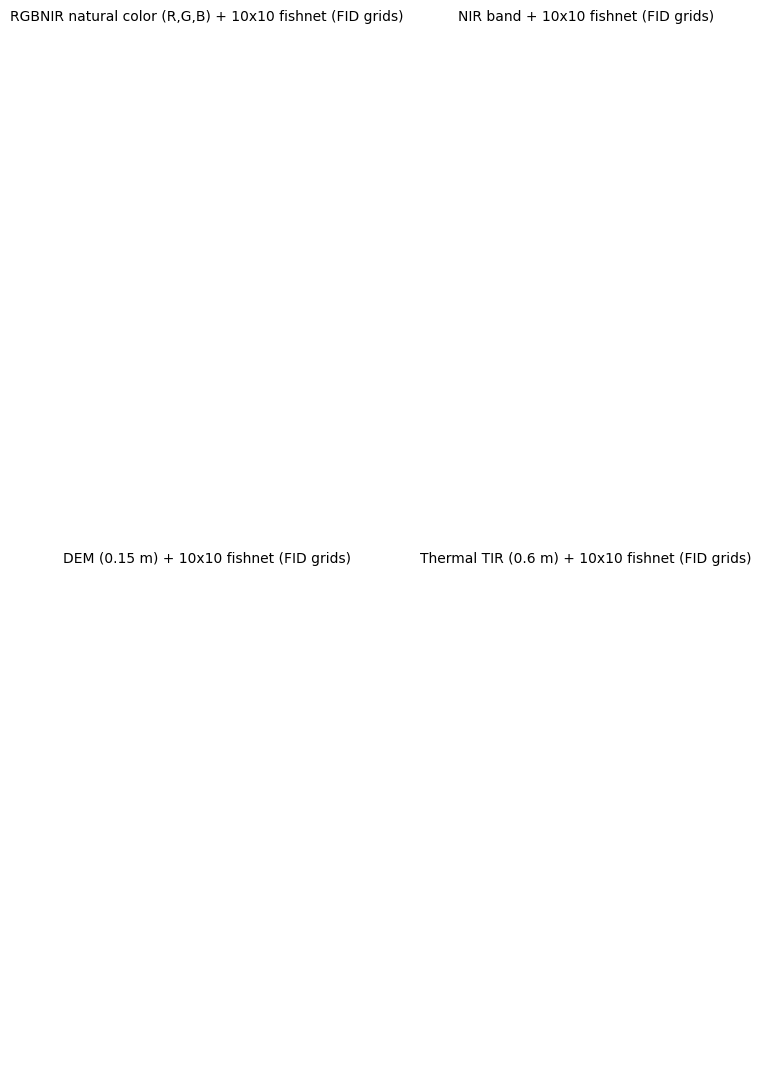

RGBNIR (286, 297), DEM (286, 297), TIR (72, 75) — fishnet: 100 grids


In [ ]:
# Preview the demo inputs with the fishnet grid overlay (saved as notebook PNG outputs)
import numpy as np, matplotlib.pyplot as plt, rasterio, geopandas, pathlib

DATA = pathlib.Path("/content/hydroshare_demo")
fish = geopandas.read_file(DATA / "1_Data/Fish_SLM_140809_1041.shp")

with rasterio.open(DATA / "1_Data/SLM_140809_1041_RGBNIR.tif") as ds:
    R, G, B, NIR = ds.read(1).astype(float), ds.read(2).astype(float), ds.read(3).astype(float), ds.read(4).astype(float)
    rgb_transform = ds.transform
with rasterio.open(DATA / "1_Data/SLM_140809_1041_DEM.tif") as ds:
    DEM = ds.read(1).astype(float)
with rasterio.open(DATA / "1_Data/SLM_140809_1041_TIR.tif") as ds:
    TIR = ds.read(1).astype(float)

def stretch(a):
    lo, hi = np.nanpercentile(a, [2, 98])
    return np.clip((a - lo) / (hi - lo), 0, 1)

fig, axes = plt.subplots(2, 2, figsize=(11, 11))
panels = [
    (np.dstack([stretch(R), stretch(G), stretch(B)]), "RGBNIR natural color (R,G,B)"),
    (np.dstack([stretch(NIR)]*3), "NIR band"),
    (np.repeat(stretch(DEM)[:, :, None], 3, axis=2), "DEM (0.15 m)"),
    (np.repeat(stretch(TIR)[:, :, None], 3, axis=2), "Thermal TIR (0.6 m)"),
]
for ax, (img, title) in zip(axes.flat, panels):
    ax.imshow(img)
    fish.boundary.plot(ax=ax, color="yellow", linewidth=0.4)
    ax.set_title(title + " + 10x10 fishnet (FID grids)", fontsize=10)
    ax.set_axis_off()
plt.tight_layout(); plt.savefig("input_preview.png", dpi=110); plt.show()
print(f"RGBNIR {R.shape}, DEM {DEM.shape}, TIR {TIR.shape} — fishnet: {len(fish)} grids")

## 6. Preprocessing port (author steps 1–3) / 前処理の移植

**EN:** Faithful port of `Fast_Approach.py` preprocessing (lines 310–452):
1. resolution check & NEAREST resample to 0.15 m (only TIR at 0.6 m needs it; RGBNIR/DEM are already 0.15 m — the check is kept and reported),
2. **Extract by mask** with `Mask_SLM_140809_1041.shp` (author: `arcpy.sa.ExtractByMask`; port: `rasterio.mask.mask`),
3. per-band scaling exactly as parameterized by the author (lines 423–452): R/G/B/NIR → no scaling, values outside [0, 10000] set to NoData; thermal → clip [−25, 70] °C, then `(°C + 273.15) × 100` (centi-Kelvin); DEM → clip [−60, 170] m, then `× 1000` (mm).
**JP:** 著者スクリプトの前処理(解像度チェックと0.15mへのNEAREST再標本化、マスク抽出、バンド毎のスケーリング)をそのまま移植します。

In [ ]:
# Port of Fast_Approach.py lines 310-452 (resolution check, mask extraction, scaling)
import numpy as np, rasterio, geopandas, pathlib
from rasterio.mask import mask as rio_mask
from rasterio.enums import Resampling
from rasterio.warp import reproject

DATA = pathlib.Path("/content/hydroshare_demo")
noDataValue = np.nan
resolution_optical = 0.15  # m, author fixed parameter (line 266)

def resample_to(src_arr, src_prof, ref_prof, resampling=Resampling.nearest):
    dst = np.full(ref_prof["shape"], noDataValue, dtype=np.float32)
    reproject(src_arr, dst, src_transform=src_prof["transform"], src_crs=src_prof["crs"],
              dst_transform=ref_prof["transform"], dst_crs=ref_prof["crs"],
              resampling=resampling)
    return dst

def open_raster(path):
    with rasterio.open(path) as ds:
        arr = ds.read().astype(float)  # (bands, h, w)
        return arr, ds.res, {"transform": ds.transform, "crs": ds.crs, "shape": (ds.height, ds.width)}

# --- optical bands (R,G,B,NIR) — author lines 310-369 ---
arr_opt, res_opt, prof_opt = open_raster(DATA / "1_Data/SLM_140809_1041_RGBNIR.tif")
print(f"optical resolution {res_opt[0]:.3f} x {res_opt[1]:.3f} m", "-> no resample needed" if abs(res_opt[0]-0.15)<1e-6 else "-> RESAMPLE")
R_raw, G_raw, B_raw, NIR_raw = arr_opt[0], arr_opt[1], arr_opt[2], arr_opt[3]

# --- DEM (author lines 371-394) ---
DEM_raw, res_dem, prof_dem = open_raster(DATA / "1_Data/SLM_140809_1041_DEM.tif")
print(f"DEM resolution    {res_dem[0]:.3f} x {res_dem[1]:.3f} m", "-> no resample needed" if abs(res_dem[0]-0.15)<1e-6 else "-> RESAMPLE")
DEM_raw = DEM_raw[0]

# --- thermal (author lines 396-419): 0.6 m -> NEAREST resample onto the optical grid ---
TIR_raw, res_tir, prof_tir = open_raster(DATA / "1_Data/SLM_140809_1041_TIR.tif")
print(f"TIR resolution    {res_tir[0]:.3f} x {res_tir[1]:.3f} m", "-> NEAREST resample to 0.15 m")
TIR_15m = resample_to(TIR_raw[0], prof_tir, prof_opt, Resampling.nearest)

# --- ExtractByMask with the research-area mask (author line 149) ---
mask_gdf = geopandas.read_file(DATA / "1_Data/Mask_SLM_140809_1041.shp")
geoms = [g.__geo_interface__ for g in mask_gdf.geometry]

def extract_by_mask(arr, prof):
    with rasterio.MemoryFile() as mem:
        with mem.open(driver="GTiff", height=prof["shape"][0], width=prof["shape"][1],
                      count=1, dtype="float32", transform=prof["transform"], crs=prof["crs"],
                      nodata=noDataValue) as ds:
            ds.write(arr.astype(np.float32), 1)
        with mem.open() as ds:
            out, _ = rio_mask(ds, geoms, crop=False, filled=True, nodata=noDataValue)
    return out[0].astype(float)

R_m, G_m, B_m, NIR_m = (extract_by_mask(a, prof_opt) for a in (R_raw, G_raw, B_raw, NIR_raw))
DEM_m = extract_by_mask(DEM_raw, prof_dem)
TIR_m = extract_by_mask(TIR_15m, prof_opt)

# --- NeedScaleOrNot parameter sets (author lines 423-452) ---
def scale_band(arr, lo, hi, add, mult):
    a = arr.copy()
    a[a < lo] = noDataValue; a[a > hi] = noDataValue
    return (a + add) * mult

R_s, G_s, B_s, NIR_s = (scale_band(a, 0, 10000, 0, 1) for a in (R_m, G_m, B_m, NIR_m))  # Scale "No": bounds only, no arithmetic (author AddRatio_1=1 is ignored when Scale="No")
Tr_s = scale_band(TIR_m, -25, 70, 273.15, 100)   # Scale "Yes" type 1: +273.15, x100
DEM_s = scale_band(DEM_m, -60, 170, 0, 1000)     # Scale "Yes" type 1: +0, x1000 (mm)
print("Preprocessing done: R,G,B,NIR in [0,10000]; Tr centi-K; DEM mm; all masked to research area.")

optical resolution 0.150 x 0.150 m -> no resample needed
DEM resolution    0.150 x 0.150 m -> no resample needed
TIR resolution    0.600 x 0.600 m -> NEAREST resample to 0.15 m
Preprocessing done: R,G,B,NIR in [0,10000]; Tr centi-K; DEM mm; all masked to research area.


## 7. Per-grid feature extraction (author core loop) / グリッド毎の特徴量抽出

**EN:** Port of the author's core loop (lines 459–653). For each fishnet grid `FID = 0..99`:
- clip the six scaled bands (R, G, B, NIR, Tr, DEM) to that grid polygon (author: `arcpy.management.Clip` with polygon mask; port: boolean pixel mask),
- compute `NDVI = (NIR − R)/(NIR + R)`; apply the author's soil rule (`Soil_NDVI_Threshold = 0.45`, line 243): the lowest NDVI of the **first** grid (FID 0) must be ≤ 0.45; if it is, each grid's DEM is demeaned by its own minimum (relative height), otherwise all grids use grid 0's minimum,
- `statistics()` (lines 459–473): keep values ≥ 0, then max/min/mean/std/P25/P50/P75 per band → 42 features,
- cast to `int` exactly like the author (`df.astype(int)`, line 698).

Author `statistics()` is reproduced verbatim; `np.nanstd` (population, ddof=0) matches.
**JP:** 著者の本体ループを移植します。各魚網グリッドで6バンドをクリップし、NDVI土壌判定(閾値0.45)とDEM相対高さ処理を行い、≥0の画素に対してmax/min/mean/std/P25/P50/P75を計算し、著者と同様にint型へキャストします。

In [ ]:
# Port of the author's per-grid loop (Fast_Approach.py lines 525-653) with verbatim statistics()
import numpy as np, geopandas, pandas as pd, pathlib, rasterio
from rasterio.features import geometry_mask

DATA = pathlib.Path("/content/hydroshare_demo")
START, END = 0, 100            # author lines 241-242
Soil_NDVI_Threshold = 0.45    # author line 243
fish = geopandas.read_file(DATA / "1_Data/Fish_SLM_140809_1041.shp")
assert len(fish) == 100, f"expected 100 fishnet grids, got {len(fish)}"

def statistics(inputArray):
    # verbatim port of author lines 459-473
    inputArray = inputArray[inputArray >= 0]
    MAX = np.nanmax(inputArray); MIN = np.nanmin(inputArray)
    MEAN = np.nanmean(inputArray); STD = np.nanstd(inputArray)
    P25 = np.nanpercentile(inputArray, 25); P50 = np.nanpercentile(inputArray, 50)
    P75 = np.nanpercentile(inputArray, 75)
    return (MAX, MIN, MEAN, STD, P25, P50, P75)

BANDS = {"R": R_s, "G": G_s, "B": B_s, "NIR": NIR_s, "Tr": Tr_s, "DEM": DEM_s}
stats_per_band = {b: [] for b in BANDS}
tmp_lowest_DEM = 0            # author line 523
tmp_lowest_NDVI = None

with rasterio.open(DATA / "1_Data/SLM_140809_1041_RGBNIR.tif") as ds:
    grid_transform, grid_shape = ds.transform, (ds.height, ds.width)

for i in range(START, END):                     # author line 525: 100 grids
    geom = [fish.geometry.iloc[i].__geo_interface__]
    inside = geometry_mask(geometries=geom, out_shape=grid_shape,
                           transform=grid_transform, invert=True)  # True inside polygon
    clipped = {name: np.where(inside, arr, noDataValue) for name, arr in BANDS.items()}
    Array_NDVI = (clipped["NIR"] - clipped["R"]) / (clipped["NIR"] + clipped["R"])

    if i == START:                              # author lines 571-579
        tmp_lowest_NDVI = np.nanmin(Array_NDVI)
        assert tmp_lowest_NDVI <= Soil_NDVI_Threshold, (
            "No soil pixel in the 1st grid (author would break): lowest NDVI "
            f"{tmp_lowest_NDVI:.3f} > {Soil_NDVI_Threshold}")
        tmp_lowest_DEM = np.nanmin(clipped["DEM"])
        clipped["DEM"] = clipped["DEM"] - tmp_lowest_DEM
    else:                                       # author lines 588-609
        if tmp_lowest_NDVI > Soil_NDVI_Threshold:
            clipped["DEM"] = clipped["DEM"] - tmp_lowest_DEM
        else:
            tmp_lowest_DEM = np.nanmin(clipped["DEM"])
            clipped["DEM"] = clipped["DEM"] - tmp_lowest_DEM

    for name, arr in clipped.items():
        stats_per_band[name].append(statistics(arr.ravel()))
    if (i + 1) % 25 == 0:
        print(f"processed grid {i + 1}/100")

# Column order exactly as author lines 654-697
df = pd.DataFrame()
for stat, sidx in [("75", 6), ("50", 5), ("25", 4), ("std", 3), ("mean", 2), ("min", 1), ("max", 0)]:
    for band in ["DEM", "Tr", "NIR", "B", "G", "R"]:
        df[f"{band}_{stat}"] = [s[sidx] for s in stats_per_band[band]]
df = df.astype(int)                             # author line 698
print("feature table:", df.shape, "-> 42 features x 100 grids")

processed grid 25/100
processed grid 50/100


processed grid 75/100
processed grid 100/100
feature table: (100, 42) -> 42 features x 100 grids


## 8. Results / 結果

**EN:** Show the regenerated 42-feature table (first rows, descriptive summary) and export it as CSV inside Colab. Units follow the author scaling: Tr in centi-Kelvin, DEM relative height in mm, reflectance bands on their original 0–10000 scale.
**JP:** 再生成した42特徴量テーブルを表示し、CSVとして保存します。単位は著者のスケーリングに従います。

In [ ]:
# Inspect and export the regenerated feature table
import pandas as pd
print(df.iloc[:5, :8].to_string())
print("\n... (42 columns total; showing first 8)")
summary = df.describe().T[["mean", "std", "min", "max"]]
print(summary.to_string())
df.to_csv("/content/SLM_140809_1041_Fast_port.csv", index=False)
print("saved /content/SLM_140809_1041_Fast_port.csv")

   DEM_75  Tr_75  NIR_75  B_75  G_75  R_75  DEM_50  Tr_50
0     700  31616    3119   559   863  1053     583  31589
1     270  31594    3066   550   863  1053     212  31583
2     459  31618    2999   579   896  1134     393  31598
3     627  31617    3029   598   918  1148     501  31591
4     530  31653    3119   598   907  1162     439  31623

... (42 columns total; showing first 8)
              mean         std      min      max
DEM_75      587.80  215.756971    270.0   1516.0
Tr_75     31572.70  115.711021  31176.0  31759.0
NIR_75     2932.91  178.905149   2579.0   3239.0
B_75        601.14   25.726620    540.0    655.0
G_75        893.02   32.583376    808.0    951.0
R_75       1162.62   60.450293   1026.0   1298.0
DEM_50      470.56  192.666683    212.0   1279.0
Tr_50     31512.65  128.586596  31116.0  31700.0
NIR_50     2699.00   73.329890   2489.0   2879.0
B_50        562.37   32.205356    482.0    636.0
G_50        844.01   39.956162    753.0    929.0
R_50       1092.29   66

## 9. Validation against the authors' reference output / 著者参照出力との検証

**EN:** The authors published their Fast-approach output (`SLM_140809_1041_Fast.csv`, 100 records × 42 features). We compare the ported pipeline's integer table cell-by-cell against it: exact-match rate, per-column match rates, and max absolute difference. A graph (port vs reference for one representative feature) is generated for this notebook — it is **not** an author figure.
**JP:** 著者が公開している参照CSVとセル単位で照合します(一致率・列毎の一致率・最大絶対差)。グラフは本ノートブック用に作成したものであり、著者の図ではありません。

table shape: ours (100, 42), reference (100, 42)
exact cell matches: 4200/4200 = 100.00%
max abs diff: 0 | mean abs diff: 0.000
columns with any mismatch:
  none — all 42 columns match exactly


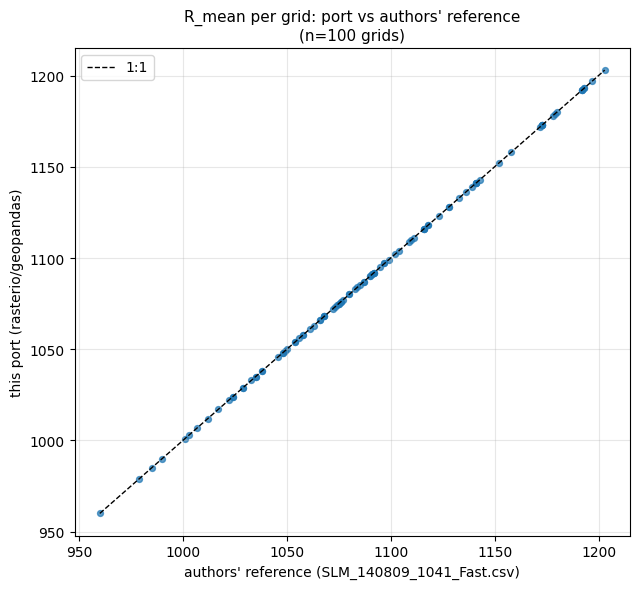

In [ ]:
# Cell-by-cell comparison with the authors' reference CSV
import pandas as pd, numpy as np, matplotlib.pyplot as plt, pathlib

DATA = pathlib.Path("/content/hydroshare_demo")
ref = pd.read_csv(DATA / "3_Feature_Extraction_Results/SLM_140809_1041_Fast.csv")
assert list(ref.columns) == list(df.columns), (
    f"column mismatch:\n ref={list(ref.columns)[:8]}...\n ours={list(df.columns)[:8]}...")

ref_v, our_v = ref.values.astype(int), df.values.astype(int)
exact = (ref_v == our_v)
print(f"table shape: ours {our_v.shape}, reference {ref_v.shape}")
print(f"exact cell matches: {exact.sum()}/{exact.size} = {100*exact.mean():.2f}%")
diff = np.abs(ref_v - our_v)
print(f"max abs diff: {diff.max()} | mean abs diff: {diff.mean():.3f}")
col_match = pd.Series(exact.mean(axis=0), index=ref.columns)
print("columns with any mismatch:")
print(col_match[col_match < 1.0].to_string() if (col_match < 1.0).any() else "  none — all 42 columns match exactly")

fig, ax = plt.subplots(figsize=(6.5, 6))
feat = "R_mean"
ax.scatter(ref_v[:, list(ref.columns).index(feat)], our_v[:, list(df.columns).index(feat)], s=18, alpha=0.7)
lims = [min(ref_v[:, list(ref.columns).index(feat)].min(), our_v[:, list(df.columns).index(feat)].min()),
        max(ref_v[:, list(ref.columns).index(feat)].max(), our_v[:, list(df.columns).index(feat)].max())]
ax.plot(lims, lims, "k--", lw=1, label="1:1")
ax.set_xlabel("authors' reference (SLM_140809_1041_Fast.csv)")
ax.set_ylabel("this port (rasterio/geopandas)")
ax.set_title(f"{feat} per grid: port vs authors' reference\n(n=100 grids)", fontsize=11)
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("port_vs_reference.png", dpi=110); plt.show()

## 10. Interpretation, differences, validation record / 解釈・差分・検証記録

**EN:**
- **What was executed:** the paper's sUAS Fast Feature Extraction on the AggieAir demo flight `SLM_140809_1041` (RGBNIR 0.15 m, DEM 0.15 m, TIR 0.6 m → 0.15 m; 100 fishnet grids of 3.6 m × 3.6 m), regenerating the 42 ML predictor features per grid and comparing them with the authors' published reference table.
- **Interpretation:** the features summarize per-grid statistics (max/min/mean/std/percentiles) of reflectance, temperature and relative canopy height — the predictor set the paper feeds to its ML models. One 100-grid demo flight verifies the *pipeline*, not the paper's published LAI accuracies.
- **Known differences from the author implementation:** (1) ArcGIS `Resample`/`ExtractByMask`/`Clip` replaced by rasterio nearest resampling and polygon pixel-center masks — grid-edge pixels may differ by ±1 pixel; (2) `df.astype(int)` truncation retained. Any mismatch beyond ±1–2 units per cell should be examined against these causes.
- **Not verified here:** Full feature extraction (202/35 features, point cloud `SLM_140809_1041_PC.las`), ground LAI-2200C processing, RF/RVM/XGBoost training and the paper's accuracy metrics (not publicly materialized).
- **Provenance:** HydroShare resource `923cf9a7a3bb49369a4e65d48237002b` (CC BY 4.0), `Fast_Approach.py` SHA-256 `f91970e3...7455bb3`; validation reference `SLM_140809_1041_Fast.csv`. PhenoPaper investigation used as prior research guidance: `p-744e01868519d1b75843047a6938744a-20261008T044151Z-719880`.

**JP:** 本ノートブックで実行したのは、AggieAirデモ飛行データに対するFast特徴量抽出(42特徴量×100グリッド)と、著者参照テーブルとの照合です。arcpyとrasterioのマスク/再標本化の差によりグリッド端で±1画素程度の差が生じ得ます。点群を用いたFull特徴量抽出・LAI-2200C処理・RF/RVM/XGBoost学習は本検証の対象外です。